# CNN_Crack_PreTrained_DenseNet

### 표면의 Crack 여부를 파악하는 시스템을 PreTrained DenseNet을 이용한 CNN으로 구현하라
### (Colab을 사용하는 경우 "files/crack.zip"을 "내 드라이브/files/"에 복사)

>### Load modules

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0


> ### Load Data

In [ ]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [ ]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/[SOL]LAB_10_CNN_Crack_PreTrained_DenseNet/files/crack.zip
  files_path = '/content/crack'
else :
  files_path = '../files/crack/crack'

In [ ]:
# 1. 데이터 읽기

In [ ]:
%%time
first = True
IMG_SIZE = 64
for ind in range(0, 2, 1) :
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

/content/crack/0/*.*
/content/crack/1/*.*
CPU times: user 1.5 s, sys: 272 ms, total: 1.78 s
Wall time: 2.06 s


In [ ]:
# 2. 전처리: 0 ~ 1로 변환
train_data = train_data / 255.0
test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(3200, 64, 64, 3)
(3200,)
(800, 64, 64, 3)
(800,)


In [ ]:
# 3. DenseNet121 모델의 summary 출력
model_dense = tf.keras.applications.densenet.DenseNet121(
    weights="imagenet",
    include_top=True,
    input_tensor=tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model_dense.summary()

33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 70, 70, 3)      │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 32, 32, 64)     │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 32, 32, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 32, 32, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 34, 34, 64)     │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 16, 16, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 16, 16, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 16, 16, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 16, 16, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 16, 16, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 16, 16, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 16, 16, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 8,062,504 (30.76 MB)

 Trainable params: 7,978,856 (30.44 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
# 4. Keras Model 정의, Model summary
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(tf.keras.applications.densenet.DenseNet121(
    # 경로가 막혀 자동 다운로드가 안 될 경우 아래 링크를 클릭하여 파일 다운로드 받고,
    # 그 경로를 아래 weights에 설정
    # weights='../files/densenet121.h5',
    weights="imagenet",
    include_top=False,    # dense layer 이후는 제외
    ))

# Dense layers
model.add(tf.keras.layers.Flatten(name='flatten'))
model.add(tf.keras.layers.Dense(1024, name='dense_1024'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(tf.keras.layers.Dense(2, activation='softmax', name='dense_10'))

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 2, 2, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1024 (Dense)                   │ (None, 1024)                │       4,195,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 2)                   │           2,050 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,238,978 (42.87 MB)

 Trainable params: 11,153,282 (42.55 MB)

 Non-trainable params: 85,696 (334.75 KB)

In [ ]:
# 5. Model compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 6. Make_Result_Plot() 함수 정의 -> 출력 정보에 정답 여부 출력 (정답은 O, 오답은 X)
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(22, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {} / {})".format(cnt, label[cnt], y_max[cnt], 'O' if label[cnt] == y_max[cnt] else 'X'))

25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step


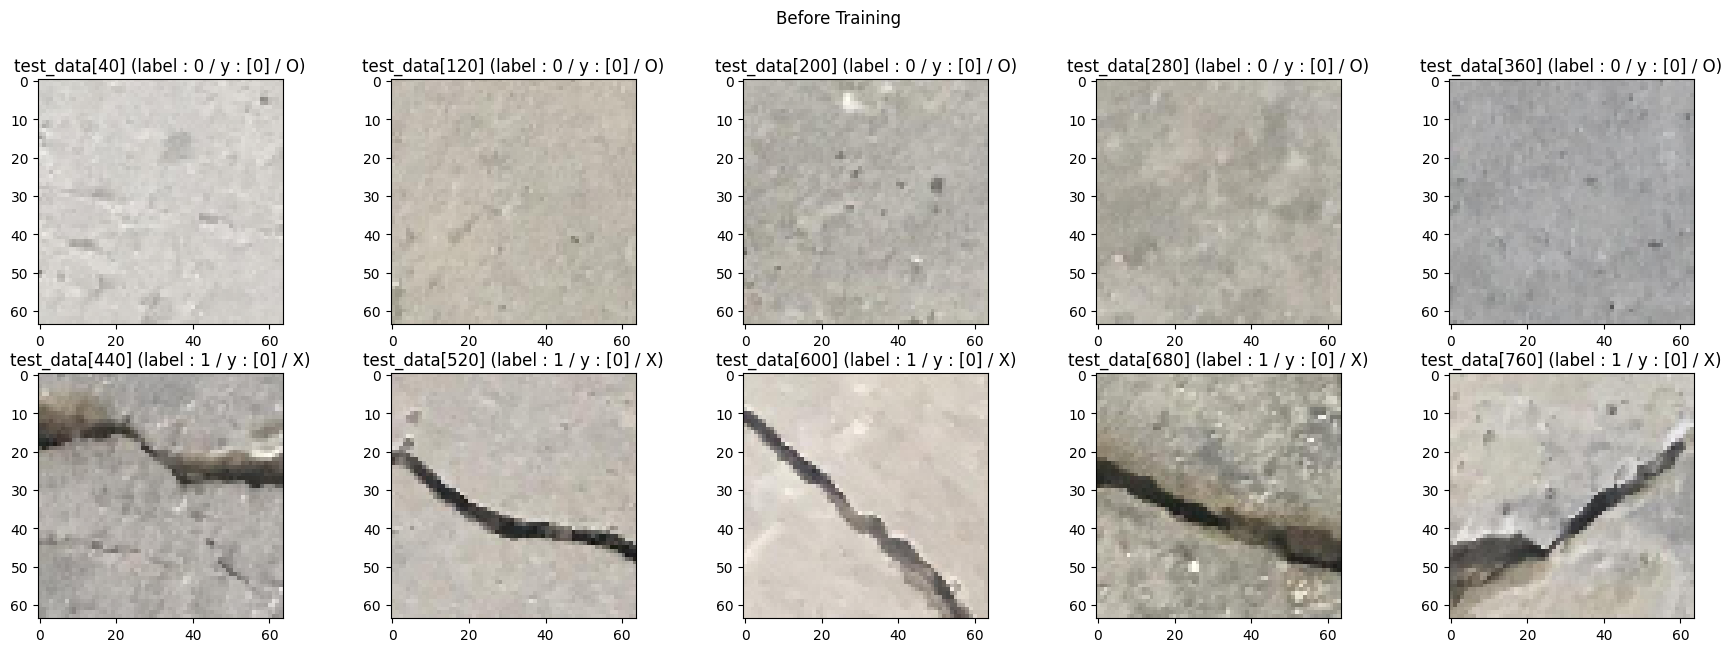

In [ ]:
# 7. 학습 전 상황 그리기
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

> ### 학습 (Training)

In [ ]:
# 8. Model fit

In [ ]:
%%time
history = model.fit(train_data, train_labels, epochs=10,
                        validation_data=(test_data, test_labels))

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 146s 156ms/step - accuracy: 0.9377 - loss: 0.2296 - val_accuracy: 0.5000 - val_loss: 402.8309
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9946 - loss: 0.0253 - val_accuracy: 0.5688 - val_loss: 23.9447
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9982 - loss: 0.0077 - val_accuracy: 0.9987 - val_loss: 0.0059
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9990 - loss: 0.0024 - val_accuracy: 0.9975 - val_loss: 0.0131
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 1.0000 - loss: 3.2179e-04 - val_accuracy: 0.9987 - val_loss: 0.0051
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9997 - loss: 6.5102e-04 - val_accuracy: 0.9950 - val_loss: 0.0233
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9958 - loss: 0.0112 - val_accuracy: 0.9987 - val_loss: 0.0084
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9959 - loss: 0

> ### Ploting : Cost/Training Count

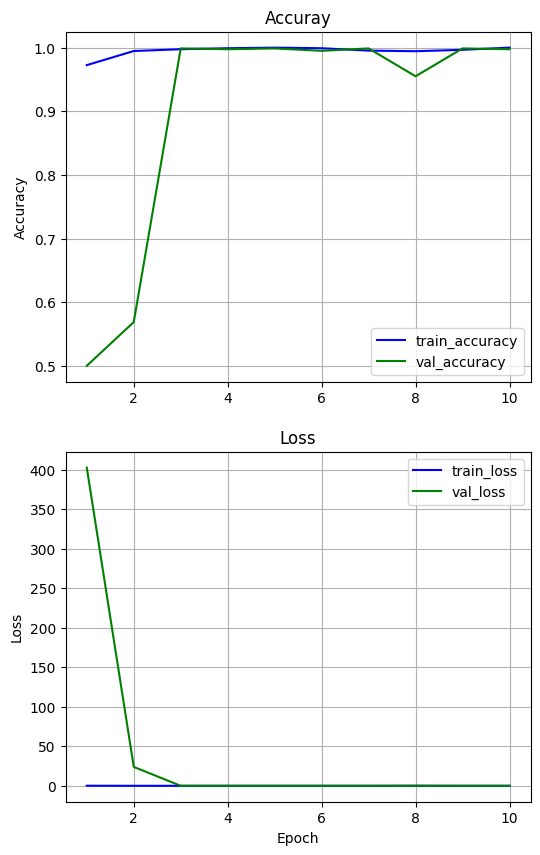

In [ ]:
# 9. accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0.8,1.2])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.plot(epochs, history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([-0.2,1.0])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


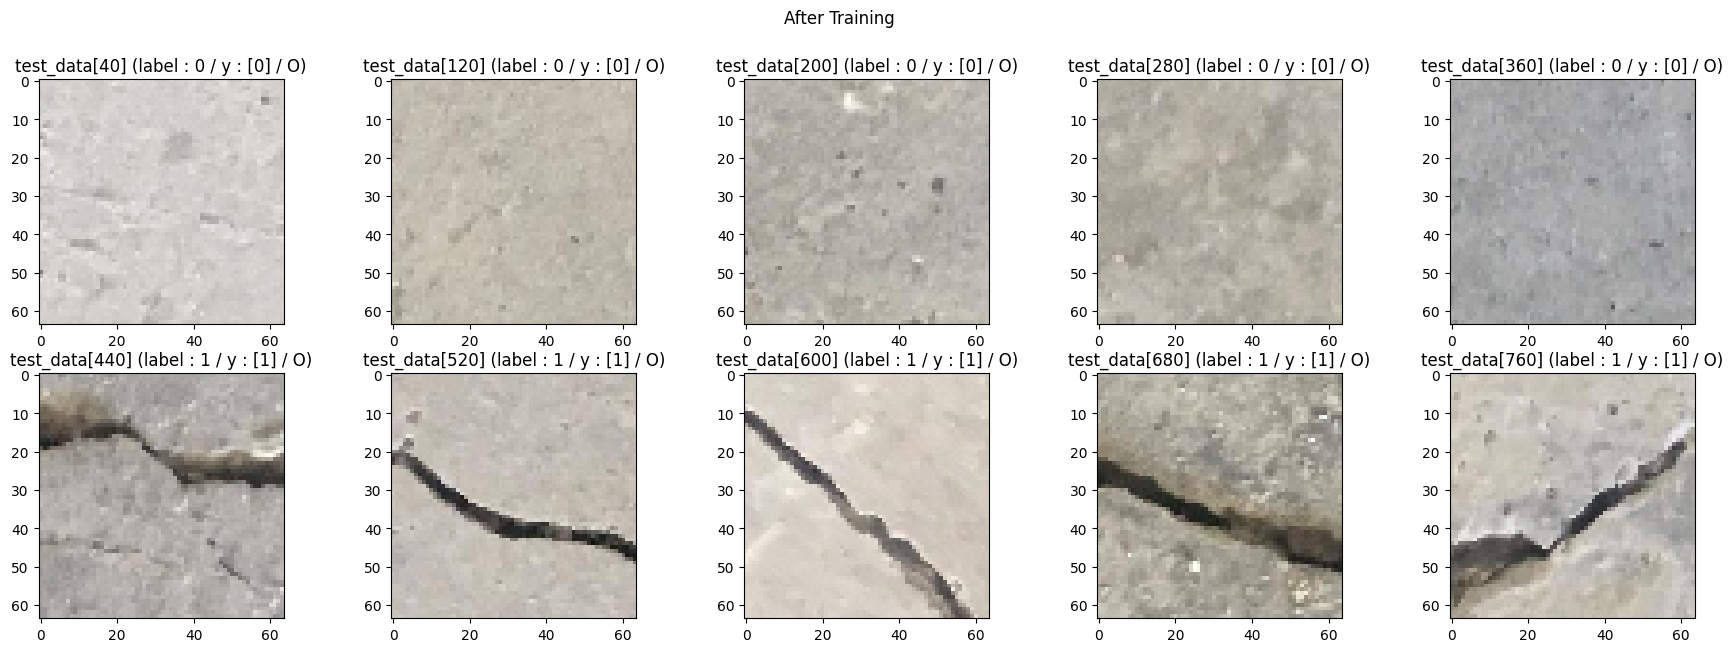

In [ ]:
# 10. 학습 후 상황 그리기
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)